<a href="https://colab.research.google.com/github/Jaffar-Kazmi/California-House-Price-Prediction/blob/main/California_House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# California House Price Prediction

Dataset: [Kaggle](https://www.kaggle.com/datasets/camnugent/california-housing-prices?resource=download)

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler



In [2]:
df = pd.read_csv("housing.csv")

In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,income_cat
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909,3.006686
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874,1.054618
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,1.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000,2.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,3.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000,4.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,5.000000


In [ ]:
df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
df['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


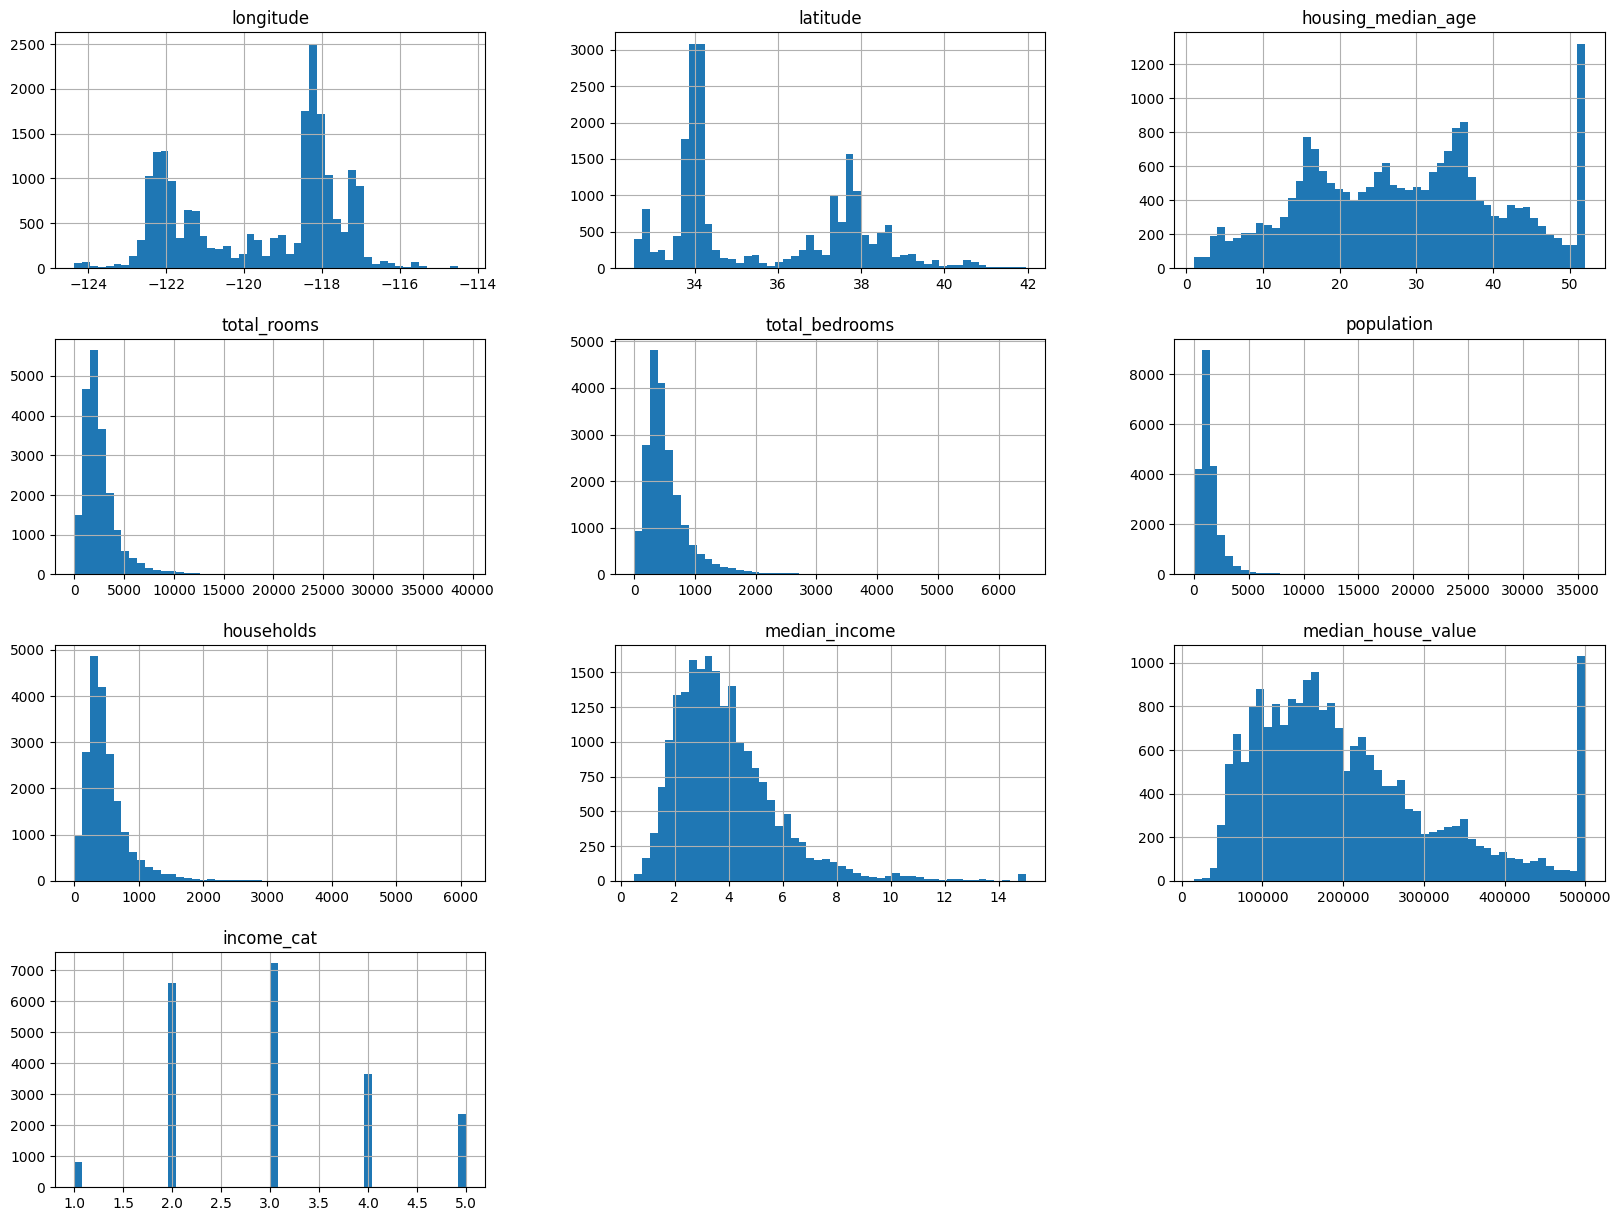

In [ ]:
df.hist(bins=50, figsize=(20, 15))
plt.show()

In [ ]:
corr_matrix = df.select_dtypes(include=[np.number]).corr()
corr_matrix = np.round((corr_matrix*100), 2)

corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,100.00
median_income,68.81
income_cat,64.39
total_rooms,13.42
housing_median_age,10.56
households,6.58
total_bedrooms,4.97
population,-2.46
longitude,-4.60
latitude,-14.42


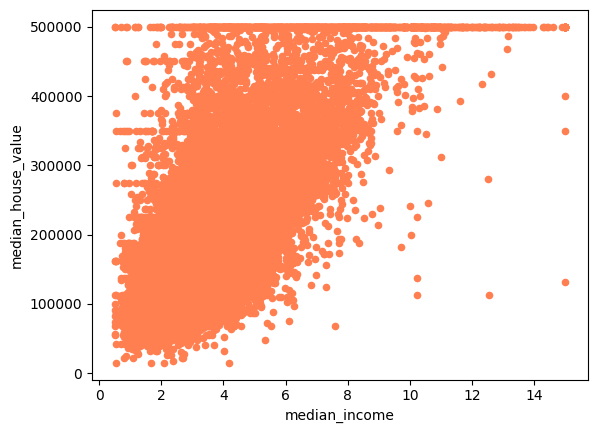

In [ ]:
df.plot(kind='scatter', x='median_income', y='median_house_value', c='coral')

plt.show()



*   This plot shows a clear **+ive relation** b/w *median income & house prices*
*   The horizontal line near 500,000 shows a price *cap in the dataset*

*   Most houses are clustered in the middle income range, with prices spread widely, so the relationship is strong but *not perfectly clean*.




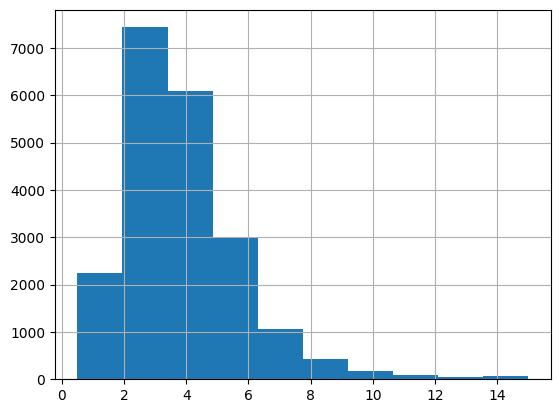

In [ ]:
df['median_income'].hist()
plt.show()



*   This shows that the data is rightly skewed
*   The majority of the data is concentrated between 2 and 5




## Train-Test Split


*   We will use **Stratified Shuffle Split** which ensures that each class is proportionally represented in training & testing datasets
*   We need to convert the continuous income into categories (otherwise Stratification becomes meaningless)*italicized text*



In [3]:
# Divides income into 5 bins
df['income_cat'] = np.ceil(df['median_income'] / 1.5)
df['income_cat'] = df['income_cat'].where(df['income_cat'] < 5, 5.0)

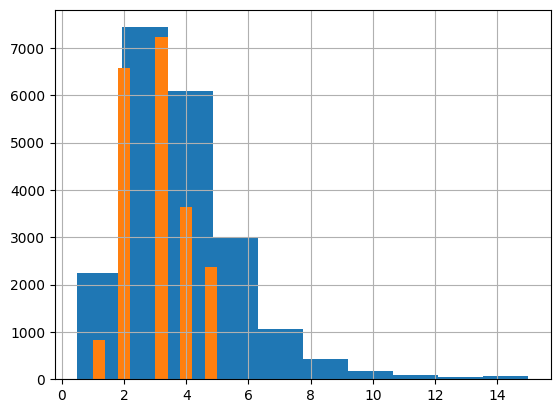

In [ ]:
# Plot histogram
df['median_income'].hist()
ax = df['income_cat'].hist()

plt.show()

In [4]:
# Split the data into 80:20
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=29)

for train_index, test_index in split.split(df, df['income_cat']):
  strat_train_set = df.loc[train_index]
  strat_test_set = df.loc[test_index]

### Compare proportion of income categories in original dataset and splitted datasets

In [ ]:
df['income_cat'].value_counts() / len(df)

,count
income_cat,
3.0,0.350581
2.0,0.318847
4.0,0.176308
5.0,0.114438
1.0,0.039826


In [ ]:
strat_test_set['income_cat'].value_counts() / len(strat_test_set)

,count
income_cat,
3.0,0.350533
2.0,0.318798
4.0,0.176357
5.0,0.114341
1.0,0.039971


### Use Simple Test train split from Sklearn & compare the results

In [ ]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

In [ ]:
def income_cat_proportions(data):
  return data['income_cat'].value_counts() / len(data)

comparing_props = pd.DataFrame({
    'Original': income_cat_proportions(df),
    'Random_Test': income_cat_proportions(test_set),
    'Stratified_Test': income_cat_proportions(strat_test_set)
}).sort_index()

In [ ]:
comparing_props['Random Error'] =  100 * comparing_props['Random_Test'] / comparing_props['Original'] - 100
comparing_props['Stratified Error'] = 100 * comparing_props['Stratified_Test'] / comparing_props['Original'] - 100

In [ ]:
comparing_props

,Original,Random_Test,Stratified_Test,Random Error,Stratified Error
income_cat,,,,,
1.0,0.039826,0.040213,0.039971,0.973236,0.364964
2.0,0.318847,0.324370,0.318798,1.732260,-0.015195
3.0,0.350581,0.358527,0.350533,2.266446,-0.013820
4.0,0.176308,0.167393,0.176357,-5.056334,0.027480
5.0,0.114438,0.109496,0.114341,-4.318374,-0.084674


In [5]:
# Drop income_cat from dataset
for item in (strat_train_set, strat_test_set):
  item.drop('income_cat', axis=1, inplace=True)

### Visualize Data in correspondance with map

In [6]:
housing = strat_train_set.copy()
testing = strat_test_set.copy()

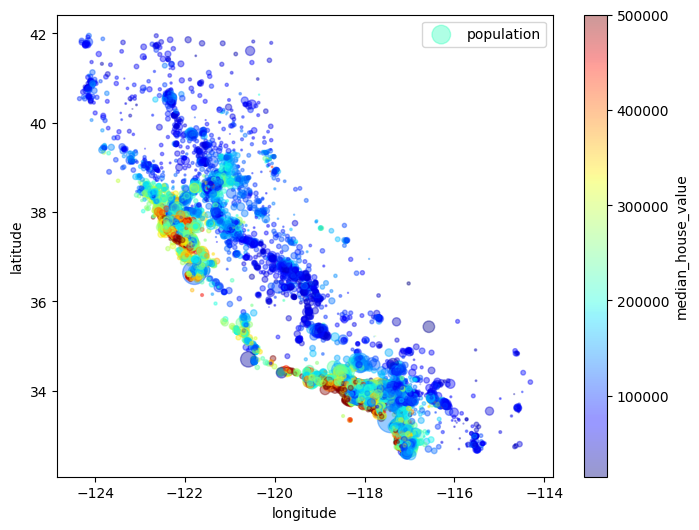

In [ ]:
housing.plot(kind='scatter', x='longitude', y='latitude', alpha=0.4,
             s=housing['population']/100, label='population', figsize=(8, 6),
             c='median_house_value', cmap=plt.get_cmap('jet'), colorbar=True)
plt.legend()

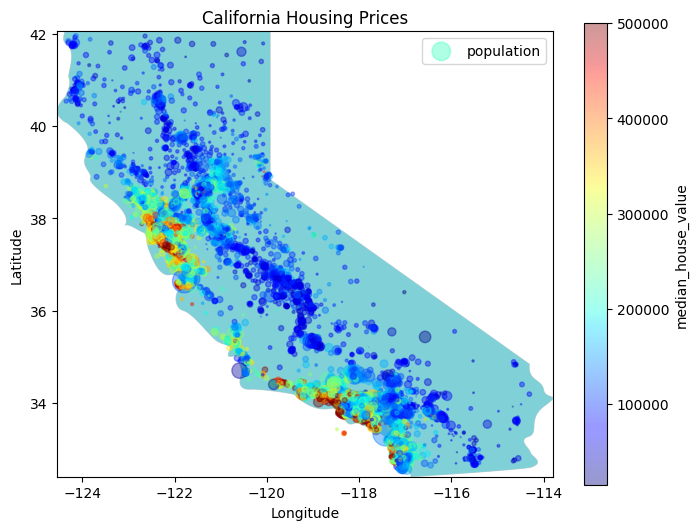

In [ ]:
import matplotlib.image as mpimg

ax = housing.plot(kind='scatter', x='longitude', y='latitude', alpha=0.4,
             s=housing['population']/100, label='population', figsize=(8, 6),
             c='median_house_value', cmap=plt.get_cmap('jet'), sharex=False)

california_img = mpimg.imread('california.png')

ax.imshow(california_img, extent=[-124.55, -113.8, 32.4, 42.05], alpha=0.5)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California Housing Prices')

plt.show()

## Feature Engineering
We introduce new features like:


1.   **Population per household**: Crowded areas usually have lower house prices
2.   **Rooms per Household**: Strong indicator of house size and luxury

3.   **Bedrooms per Room**: Lower ratio often means more desirable houses




In [7]:
housing['population_per_household'] = housing['population'] / housing['households'] # Average number of people living in each house
housing['rooms_per_household'] = housing['total_rooms'] / housing['households']     # Average number of rooms per house
housing['bedrooms_per_room'] = housing['total_bedrooms'] / housing['total_rooms']   # Fraction of rooms that are bedrooms

In [8]:
testing['population_per_household'] = testing['population'] / testing['households'] # Average number of people living in each house
testing['rooms_per_household'] = testing['total_rooms'] / testing['households']     # Average number of rooms per house
testing['bedrooms_per_room'] = testing['total_bedrooms'] / testing['total_rooms']   # Fraction of rooms that are bedrooms

In [10]:
corr_matrix = housing.select_dtypes(include=[np.number]).corr()
corr_matrix = np.round((corr_matrix * 100), 2)

corr_matrix['median_house_value'].sort_values(ascending=False)

,median_house_value
median_house_value,100.00
median_income,69.13
rooms_per_household,15.20
total_rooms,12.75
housing_median_age,10.85
households,6.02
total_bedrooms,4.40
population_per_household,-2.17
population,-2.82
longitude,-4.40


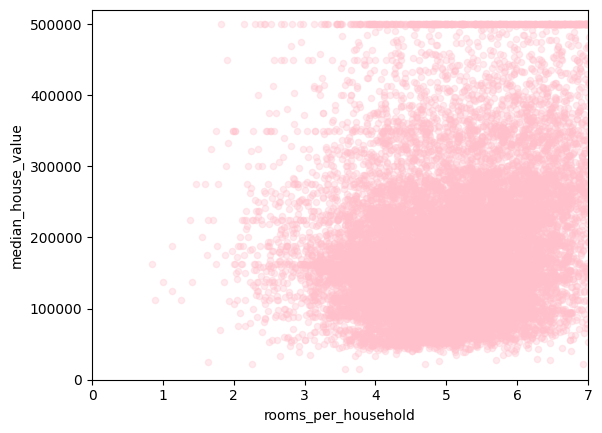

In [ ]:
housing.plot(kind='scatter', x='rooms_per_household', y='median_house_value', alpha=0.3, c='pink')
plt.axis([0, 7, 0, 520000])

plt.show()

## Data Preprocessing Pipeline

### Pipeline
A sequence of transformations followed by a final estimator (model), executed in order.

### Transformations Applied

#### 1.   Imputation
*   Fill null values with median by using **Simple Imputer**

#### 2.   Scaling
*   Standardize the features in the data in a fixed range using **Standard Scaler**

#### 3. Encoding
*   Encode the categorical attributes into numerical using **One Hot Encoder**

In the end, we combine the outcome of *numerical & categorical pipelines* using **Column Transformer**

In [9]:
X_train = housing.drop('median_house_value', axis=1)
y_train = housing['median_house_value'].copy()

In [10]:
X_test = testing.drop('median_house_value', axis=1)
y_test = testing['median_house_value'].copy()

In [11]:
num_attributes = X_train.select_dtypes(include=[np.number]).columns.tolist()

cat_attributes = ['ocean_proximity']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Handle missing values
    ('std_scalar', StandardScaler())                # Standardize data
])

cat_pipeline = Pipeline([
    ('cat_encoder', OneHotEncoder())                # Encode categorical values
])

# Combine numerical & categorical columns(transformed)
full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_attributes),
    ('cat', cat_pipeline, cat_attributes)
])

#### Visualize Data after Scaling

In [ ]:
num_data = df[num_attributes]

scaled_data = num_pipeline.fit_transform(num_data)

scaled_df = pd.DataFrame(scaled_data, columns=num_attributes)

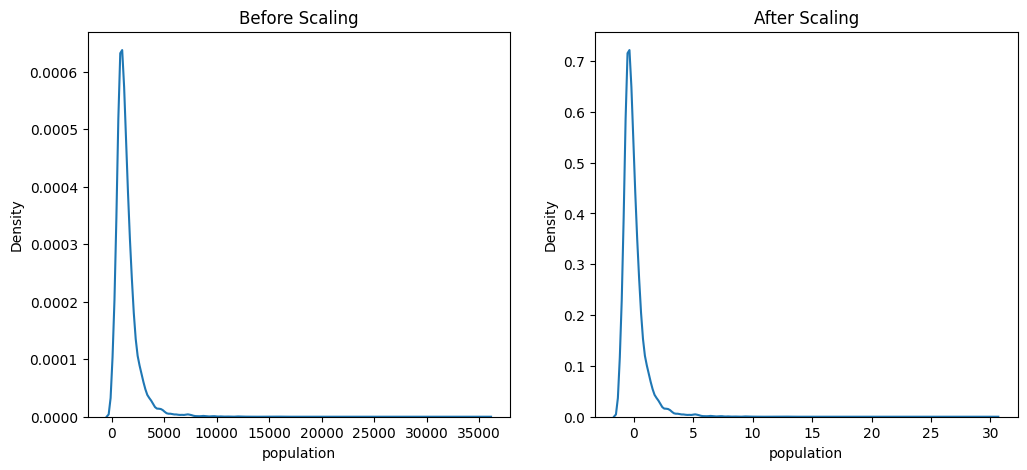

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title("Before Scaling")
sns.kdeplot(num_data['population'], ax=ax1)

ax2.set_title("After Scaling")
sns.kdeplot(scaled_df['population'], ax=ax2)

plt.show()

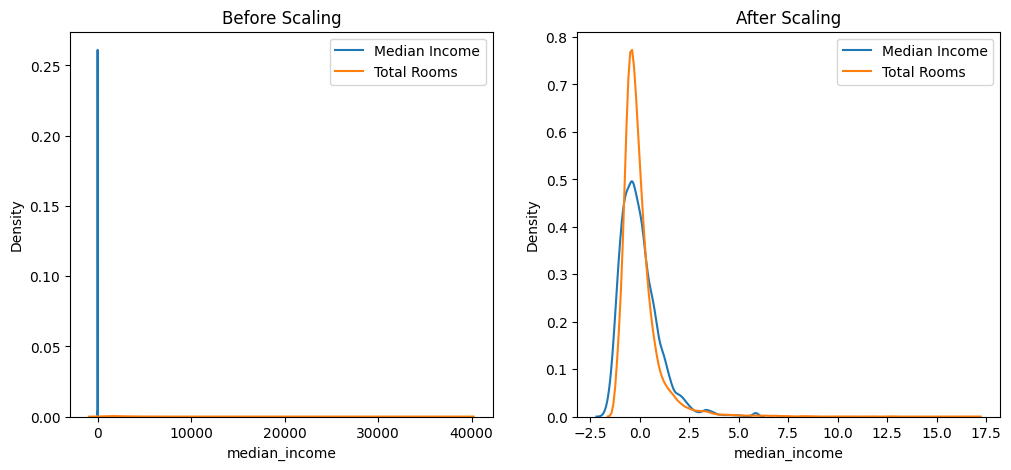

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title("Before Scaling")
sns.kdeplot(num_data['median_income'], ax=ax1, label='Median Income')
sns.kdeplot(num_data['total_rooms'], ax=ax1, label='Total Rooms')
ax1.legend()

ax2.set_title("After Scaling")
sns.kdeplot(scaled_df['median_income'], ax=ax2, label='Median Income')
sns.kdeplot(scaled_df['total_rooms'], ax=ax2, label='Total Rooms')
ax2.legend()

plt.show()

## Apply ML Models


1.   Linear Regression
2.   List item



In [21]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

models = {
    "linear": LinearRegression(),
    "ridge": Ridge(alpha=1.0),
    "lasso": Lasso(alpha=0.001, max_iter=2000),
    "tree": DecisionTreeRegressor(random_state=42),
    "random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "gradient Boosting": GradientBoostingRegressor(random_state=42),
}

results = []

for name, model in models.items():
  pipe = Pipeline([
      ("preprocessor", full_pipeline),
      ("model", model)
  ])

  r2_score = cross_val_score(pipe, X_train, y_train, scoring="r2", cv=5, n_jobs=-1)
  rmse_score = -cross_val_score(pipe, X_train, y_train, scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1)

  results.append({
      "Model": name,
      "R2_mean": r2_score.mean(),
      "R2_std": r2_score.std(),
      "RMSE_mean": rmse_score.mean(),
      "RMSE_std": rmse_score.std()
  })

results_df = pd.DataFrame(results)
print(results_df.sort_values("RMSE_mean"))



               Model   R2_mean    R2_std     RMSE_mean     RMSE_std
4      random Forest  0.814137  0.006420  49586.179007   336.242501
5  gradient Boosting  0.793189  0.006051  52314.511323   742.365185
1              ridge  0.651670  0.016991  67866.958599   823.765641
2              lasso  0.651660  0.016918  67868.201126   816.776897
0             linear  0.651660  0.016918  67868.201399   816.775942
3               tree  0.631266  0.022982  69800.938870  1150.996342


In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("preprocessor", full_pipeline),
    ("model", RandomForestRegressor(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_features": ["sqrt", "log2"],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best RMSE (CV):", -grid.best_score_)
print("Best params:", grid.best_params_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best RMSE (CV): 48628.91059288694
Best params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}


In [23]:
test_predictions = grid.predict(X_test)

In [24]:
test_predictions

array([166788.33333333, 113764.00333333,  79226.        , ...,
       163984.33333333, 327410.02333333, 146844.66666667])

In [27]:
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error

test_rmse = root_mean_squared_error(y_test, test_predictions)
test_r2 = r2_score(y_test, test_predictions)

print("Test MAE:", mean_absolute_error(y_test, test_predictions))
print("Test RMSE:", test_rmse)
print("Test MAPE:", mean_absolute_percentage_error(y_test, test_predictions))
print("Test R2:", test_r2)

Test MAE: 33159.481024709305
Test RMSE: 50433.292014079096
Test MAPE: 0.1829941693565084
Test R2: 0.8127523853129811


### Save the trained model

In [28]:
import joblib

joblib.dump(grid.best_estimator_, "house_price_model.pkl")

['house_price_model.pkl']